#### Understanding and Implementing K-Means and DBSCAN Algorithms

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Exploratory Data Analysis :

In [2]:
data = pd.read_excel('EastWestAirlines.xlsx',sheet_name=1)

In [3]:
data.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [5]:
data.shape

(3999, 12)

In [6]:
data.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [7]:
data.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


#### Outliers In Dataset :

In [8]:
for col in data.columns :
    Q3 = data[col].quantile(0.75)
    Q1 = data[col].quantile(0.25)
    IQR = Q3 - Q1
    upper_bound = Q3 + IQR*1.5
    lower_bound = Q1 - IQR*1.5
    outliers = data[(data[col]>upper_bound) | (data[col]<lower_bound)]
    print(f'outliers in {col} :',outliers.shape[0])

outliers in ID# : 0
outliers in Balance : 266
outliers in Qual_miles : 226
outliers in cc1_miles : 0
outliers in cc2_miles : 43
outliers in cc3_miles : 18
outliers in Bonus_miles : 280
outliers in Bonus_trans : 63
outliers in Flight_miles_12mo : 569
outliers in Flight_trans_12 : 565
outliers in Days_since_enroll : 0
outliers in Award? : 0


#### Replace outliers with upper bound and lower bound :

In [9]:
for col in data.columns :
    Q3 = data[col].quantile(0.75)
    Q1 = data[col].quantile(0.25)
    IQR = Q3 - Q1
    upper_bound = Q3 + IQR*1.5
    lower_bound = Q1 - IQR*1.5
    outliers = data[(data[col]>upper_bound) | (data[col]<lower_bound)]
    data[col] = data[col].clip(upper_bound,lower_bound)

#### Remove outliers :

In [10]:
for col in data.columns :
    Q3 = data[col].quantile(0.75)
    Q1 = data[col].quantile(0.25)
    IQR = Q3 - Q1
    upper_bound = Q3 + IQR*1.5
    lower_bound = Q1 - IQR*1.5
    outliers = data[(data[col]>upper_bound) | (data[col]<lower_bound)]
    print(f'outliers in {col} :',outliers.shape[0])

outliers in ID# : 0
outliers in Balance : 0
outliers in Qual_miles : 0
outliers in cc1_miles : 0
outliers in cc2_miles : 0
outliers in cc3_miles : 0
outliers in Bonus_miles : 0
outliers in Bonus_trans : 0
outliers in Flight_miles_12mo : 0
outliers in Flight_trans_12 : 0
outliers in Days_since_enroll : 0
outliers in Award? : 0


In [11]:
data = data.drop(columns=['ID#'])

#### Feature Scaling :

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

#### Visualization :

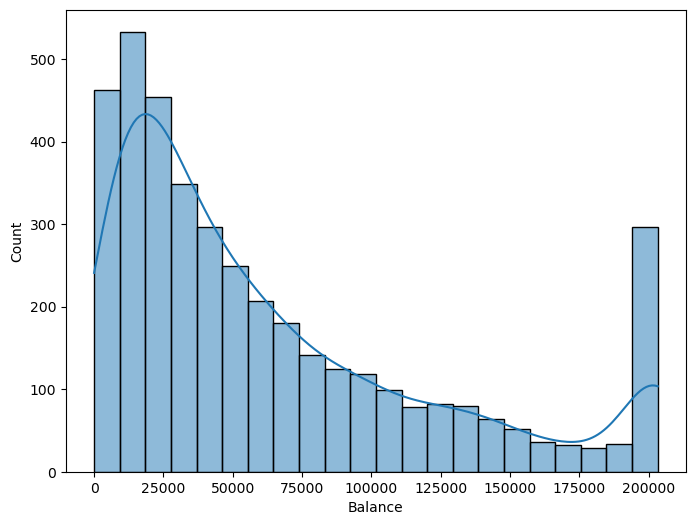

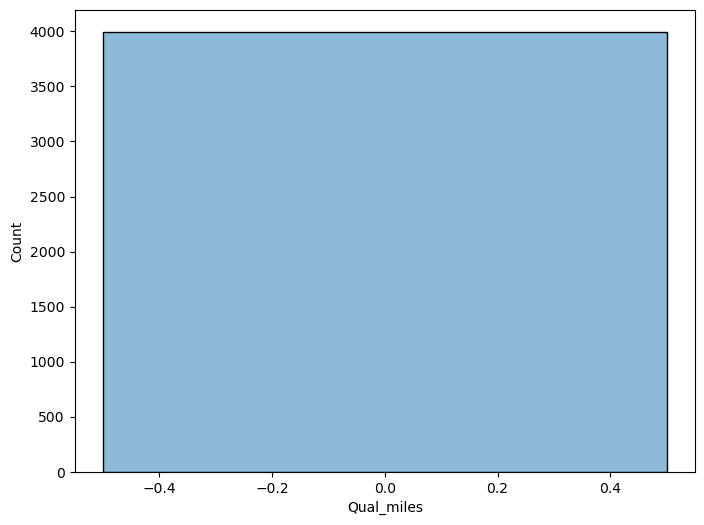

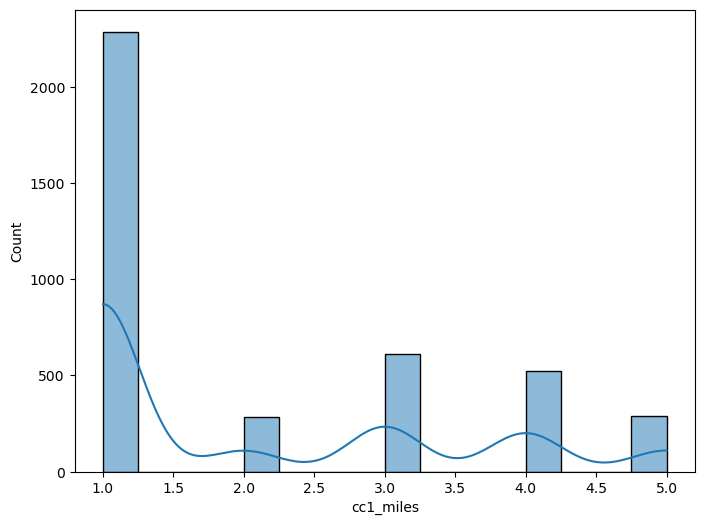

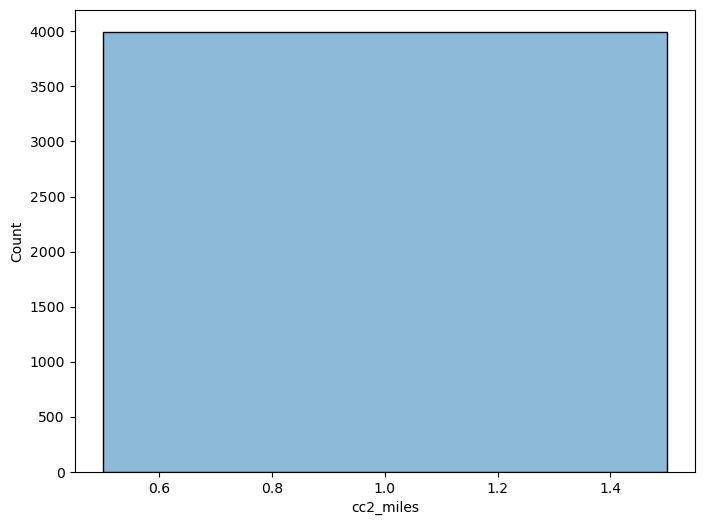

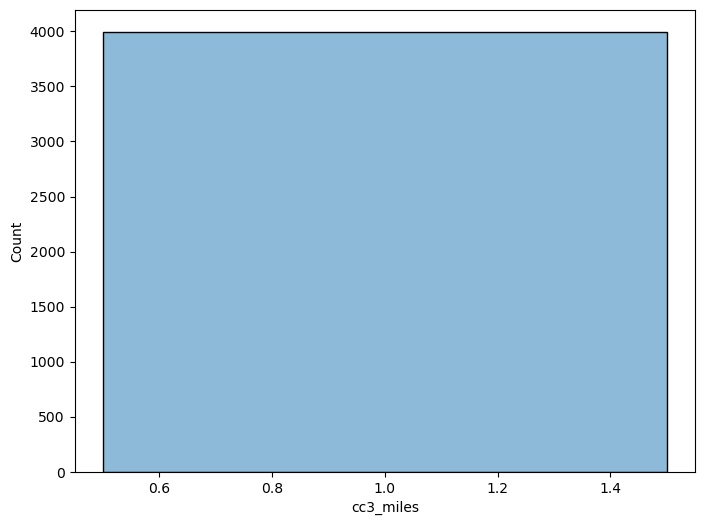

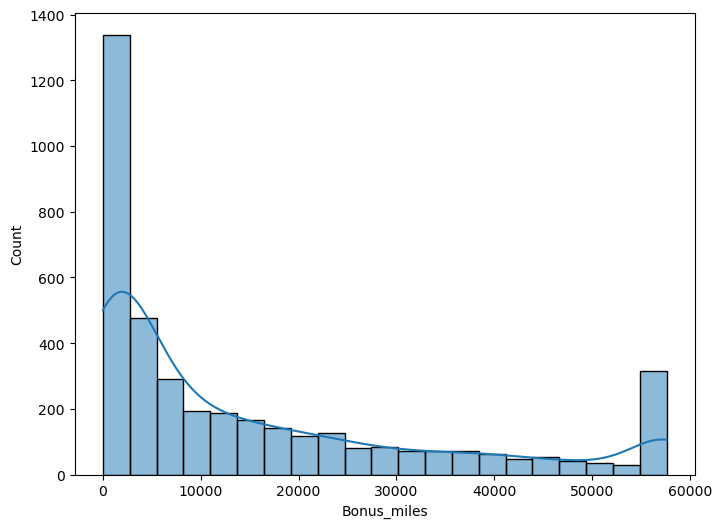

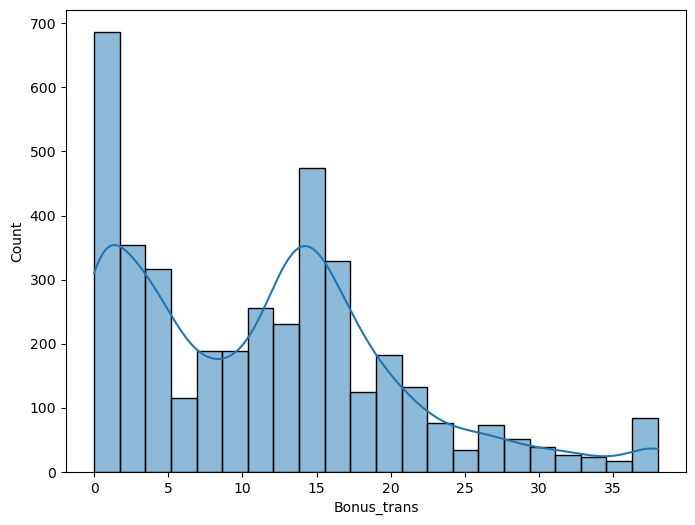

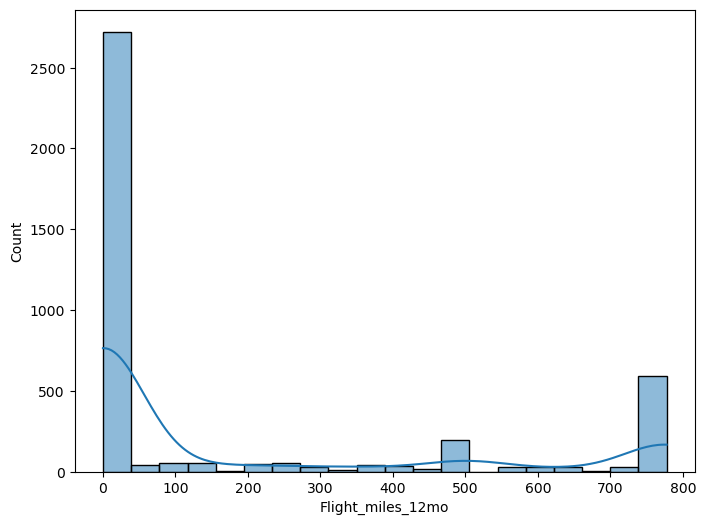

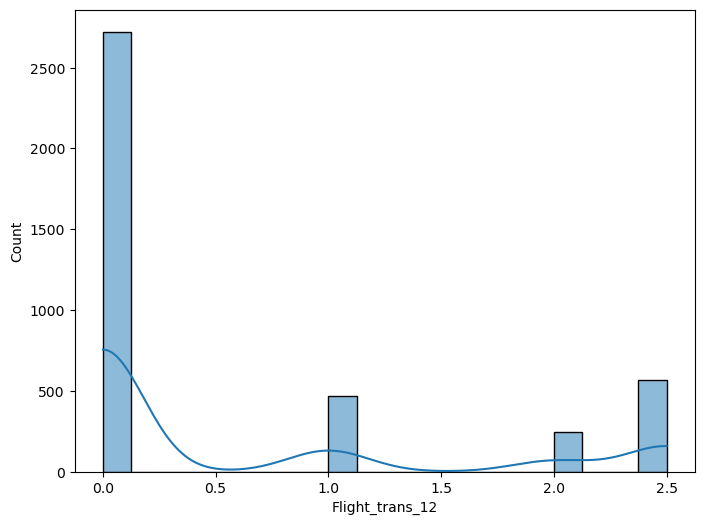

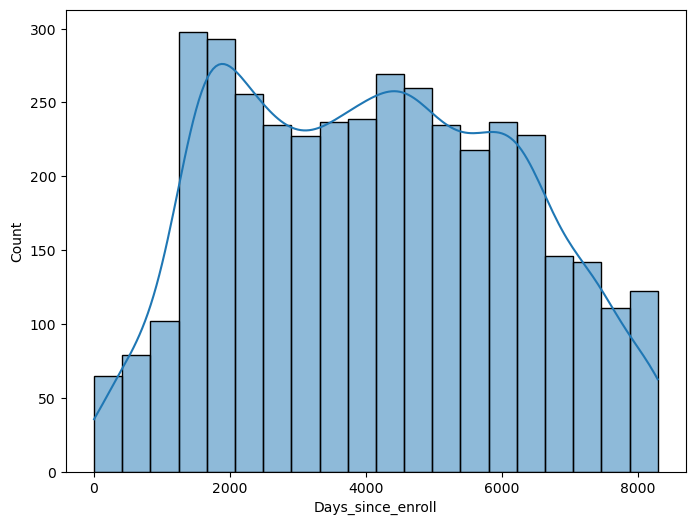

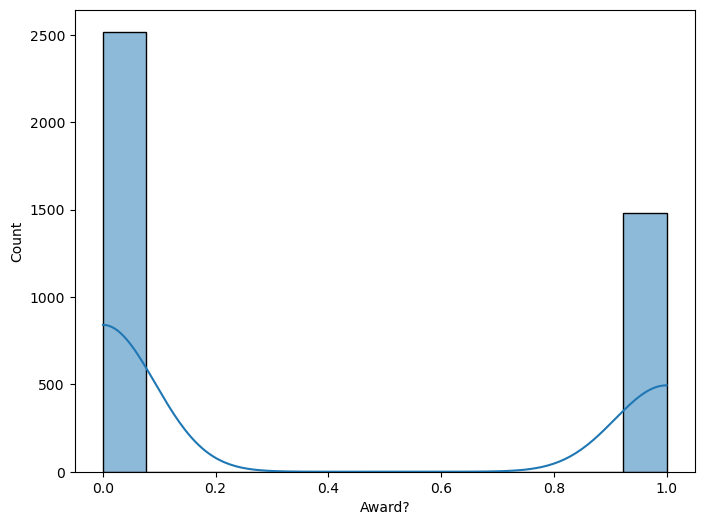

In [14]:
for col in data.columns :
    plt.figure(figsize=(8,6))
    sns.histplot(data[col],kde=True)
    plt.show()

In [15]:
for col in data.columns :
    print(f"Skewness of {col} :",data[col].skew())

Skewness of Balance : 1.1316037700975856
Skewness of Qual_miles : 0.0
Skewness of cc1_miles : 0.8575689408978102
Skewness of cc2_miles : 0.0
Skewness of cc3_miles : 0.0
Skewness of Bonus_miles : 1.1896937452684153
Skewness of Bonus_trans : 0.7284796553663152
Skewness of Flight_miles_12mo : 1.2645961180496412
Skewness of Flight_trans_12 : 1.2081640468247719
Skewness of Days_since_enroll : 0.12017356507902774
Skewness of Award? : 0.5372003821474526


### Corelational Heatmap :

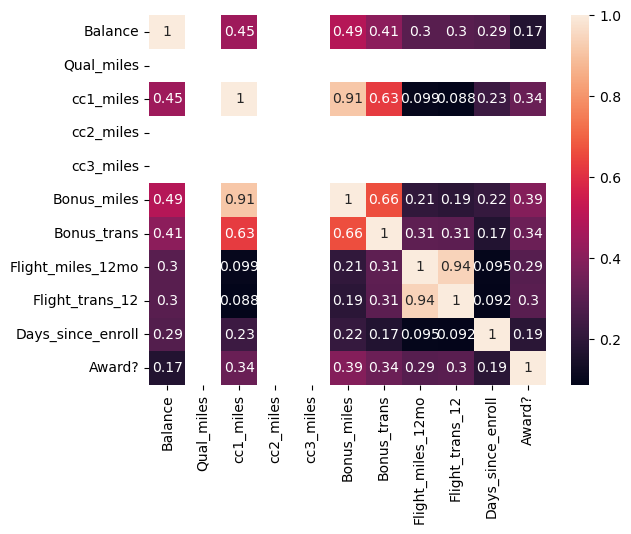

In [16]:
sns.heatmap(data.corr(),annot=True)
plt.show()

#### The ID attribute is not usefull in clustering it may creates confusion in model building so we have to drop this ID column

In [17]:
data.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143.0,0,1,1,1,174.0,1,0.0,0.0,7000,0
1,19244.0,0,1,1,1,215.0,2,0.0,0.0,6968,0
2,41354.0,0,1,1,1,4123.0,4,0.0,0.0,7034,0
3,14776.0,0,1,1,1,500.0,1,0.0,0.0,6952,0
4,97752.0,0,4,1,1,43300.0,26,777.5,2.5,6935,1


### K-Means Clustering :

#### Elbow Method :

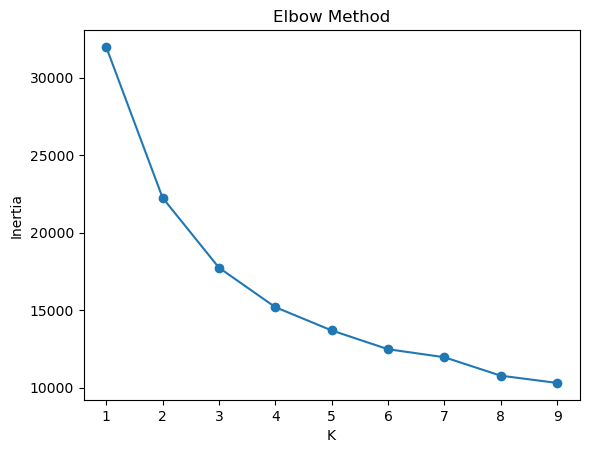

In [18]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

#### Apply K-Means :

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(scaled_data)

### DBSCAN Clustering :

In [20]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.3, min_samples=3)
labels_dbscan = dbscan.fit_predict(scaled_data)

### Visualization :

#### K-Means :

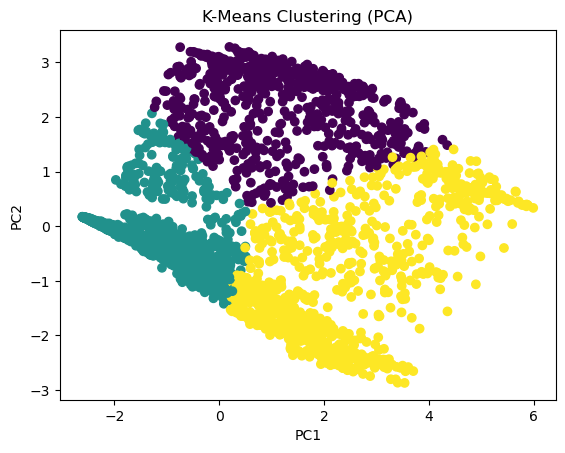

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans)
plt.title("K-Means Clustering (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#### DBSCAN :

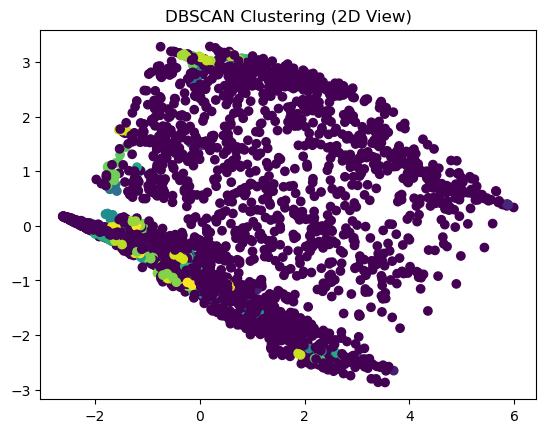

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_dbscan)
plt.title("DBSCAN Clustering (2D View)")
plt.show()

#### - The K-Means clustering results show overlapping clusters, indicating poor separation in the dataset.
#### - DBSCAN, on the other hand, grouped most of the data into a single cluster, suggesting a lack of distinct dense regions.
#### - This indicates that the dataset may not have strong clustering structure, and further preprocessing or parameter tuning is required.

### Evaluation :

In [24]:
from sklearn.metrics import silhouette_score

print("K-Means Silhouette:", silhouette_score(scaled_data, labels_kmeans))

# DBSCAN (ignore noise points: -1)
mask = labels_dbscan != -1
print("DBSCAN Silhouette:", silhouette_score(scaled_data[mask], labels_dbscan[mask]))

K-Means Silhouette: 0.32931591228742907
DBSCAN Silhouette: -0.1115352255759046


#### -K-Means outperformed DBSCAN on the given dataset.

#### -The silhouette score for K-Means was 0.329, indicating moderate cluster separation, whereas DBSCAN produced a negative silhouette score (-0.111), suggesting poor cluster formation.

#### -Therefore, K-Means was more suitable for this dataset.

In [25]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(scaled_data)

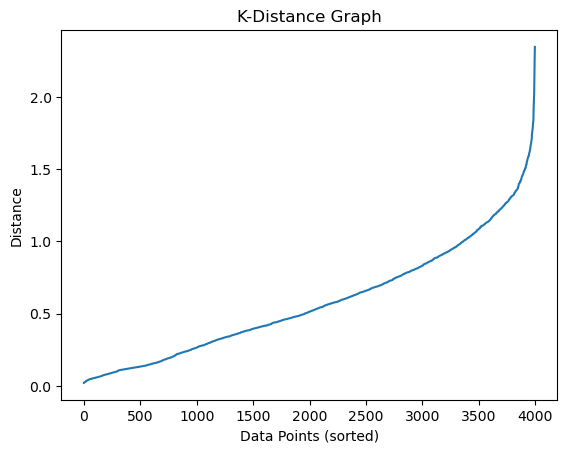

In [26]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Choose min_samples value
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(scaled_data)

distances, indices = neighbors_fit.kneighbors(scaled_data)

# Sort distances
distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.xlabel("Data Points (sorted)")
plt.ylabel("Distance")
plt.title("K-Distance Graph")
plt.show()

#### The K-Distance graph was used to determine the optimal epsilon (eps) parameter for DBSCAN. The elbow point in the graph appeared around 1.2–1.4, indicating a suitable epsilon range for density-based clustering.